In [1]:
import numpy as np
import pandas as pd
import uproot
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator

import matplotlib.pyplot as plt
from mutools.plotting import use_style
from mutools.plotting.helpers import mark_axis

use_style('rootlike')

PATH = Path('/Users/mueller/Projects/spineosc')

In [18]:
from typing import Optional
from matplotlib.lines import Line2D

def add_surface(
    ax : plt.Axes,
    surface : str,
    ci : int,
    level : Optional[float] = 1.6
) -> Line2D:
    """
    Adds a surface (output from PROfit) to the given axis. The surface is
    read from the `surf` TH2D inside PROfit's *_surf.root output, which
    carries both the chi2 grid and its axis binning.

    The file also holds a `tree` with (xbin, ybin, chi2). Those are integer
    bin INDICES (0..nbins-1), not coordinates, so the tree alone cannot
    place the contour -- the axis edges are only in the TH2D. The two agree
    exactly (max |surf - tree grid| == 0 on the current files), so the TH2D
    is read directly and no index-to-coordinate reconstruction is needed.

    Note the axes are already in linear units (sin^2(2theta) 0.01..1,
    dm^2 0.1..100, log-spaced), so the contour is drawn against the bin
    centres as-is -- unlike the old text-file version, which stored log10
    values and raised them to 10**x at plot time.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to which the surface will be added.
    surface : str
        Path to the PROfit *_surf.root file.
    ci : int
        The color index for the contour line.
    level : float, optional
        The contour level to plot (default is 1.6 for 90% CL in 1D).

    Returns
    -------
    matplotlib.lines.Line2D
        A Line2D object representing the contour line for the surface.
    """
    with uproot.open(surface) as rf:
        th2 = rf['surf']
        chi2 = th2.values()                      # (nx, ny), no under/overflow
        xedges = th2.axes[0].edges()
        yedges = th2.axes[1].edges()

    # Bin centres. The binning is logarithmic, so take geometric centres --
    # arithmetic ones would bias every contour toward the upper edge of each
    # bin, increasingly so at low x.
    xc = np.sqrt(xedges[:-1] * xedges[1:])
    yc = np.sqrt(yedges[:-1] * yedges[1:])

    # Interpolate in log space, where the grid is evenly spaced; pchip on a
    # geometrically-spaced grid would otherwise be unevenly weighted.
    interp = RegularGridInterpolator(
        (np.log10(xc), np.log10(yc)),
        chi2 - chi2.min(),
        method='pchip',
    )

    N = 125
    xg = np.logspace(np.log10(xc.min()), np.log10(xc.max()), N)
    yg = np.logspace(np.log10(yc.min()), np.log10(yc.max()), N)
    xg_mesh, yg_mesh = np.meshgrid(xg, yg, indexing='ij')
    zg = interp((np.log10(xg_mesh), np.log10(yg_mesh)))

    # Plot contour at delta chi2 = level. Axes are already linear-valued, so
    # no 10** here (the old text-file surfaces stored log10 coordinates).
    ax.contour(xg, yg, zg.T, levels=[level], linewidths=2, colors=f'C{ci}')
    return Line2D([0], [0], color=f'C{ci}')

def plot_sensitivity(
    paths : list[Path],
    labels : list[str],
    level : float = 1.6,
    savefig : Path = None,
) -> None:
    """
    Plot sensitivity curves for given paths and labels.

    Parameters
    ----------
    paths : list[Path]
        List of PROfit *_surf.root files.
    labels : list[str]
        List of labels corresponding to each sensitivity curve.
    level : float, optional
        The contour level to plot (default is 1.6 for 90% CL in 1D).
    savefig : Path, optional
        Path to save the figure. If None, the figure is not saved.

    Returns
    -------
    None.
    """
    figure = plt.figure(figsize=(8, 7))
    ax = figure.add_subplot()
    handles = []

    colors = [0, 2, 3, 4, 5]

    for ci, (file_path, label) in enumerate(zip(paths, labels)):
        handles.append(add_surface(ax, file_path, colors[ci], level=level))

    ax.set_xlabel(r'$\sin^2 2 \theta_{\mu \mu}$')
    ax.set_ylabel(r'$\Delta m_{41}^2$ [eV$^2$]')

    ax.set(xscale='log', yscale='log')
    ax.set_xlim(1e-3, 1)
    ax.set_ylim(1e-2, 1e2)

    ax.legend(handles, labels, loc='lower left')
    mark_axis(ax, r'SBN $\nu_\mu$ Disappearance', hadj=-0.025, vadj=0.12)
    mark_axis(ax, r'PROfit v3.0.0', hadj=-0.015, vadj=0.12, alignment='right')
    if savefig is not None:
        figure.savefig(savefig)

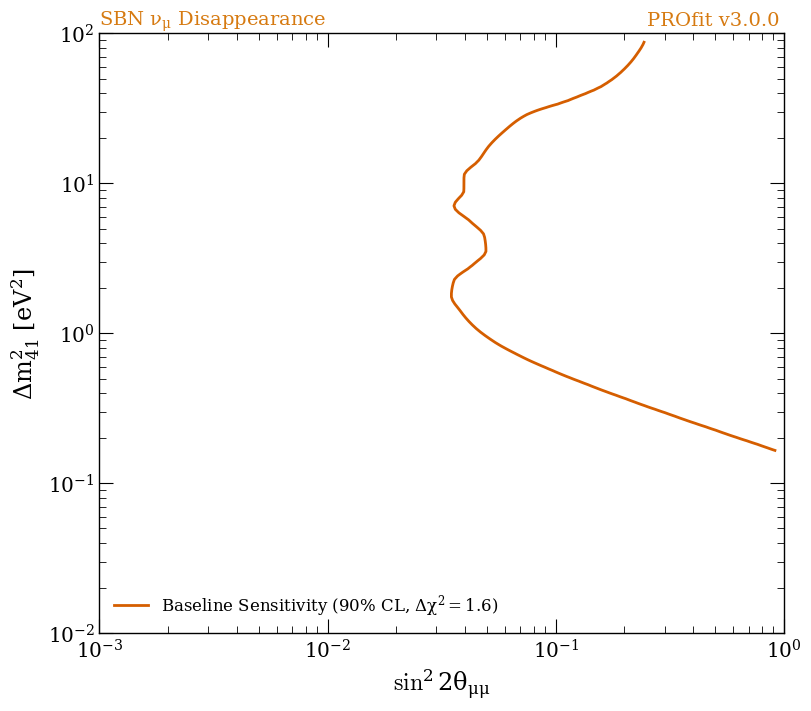

In [22]:
meta = [
    (PATH / 'contours_full_v1_surf.root', r'Baseline Sensitivity (90% CL, $\Delta \chi^2 = 1.6$)'),
]

plot_sensitivity(
    paths=[item[0] for item in meta],
    labels=[item[1] for item in meta],
    savefig='/Users/mueller/Projects/spineosc_technote/figures/sensitivity_studies/sensitivity_baseline.pdf'
)

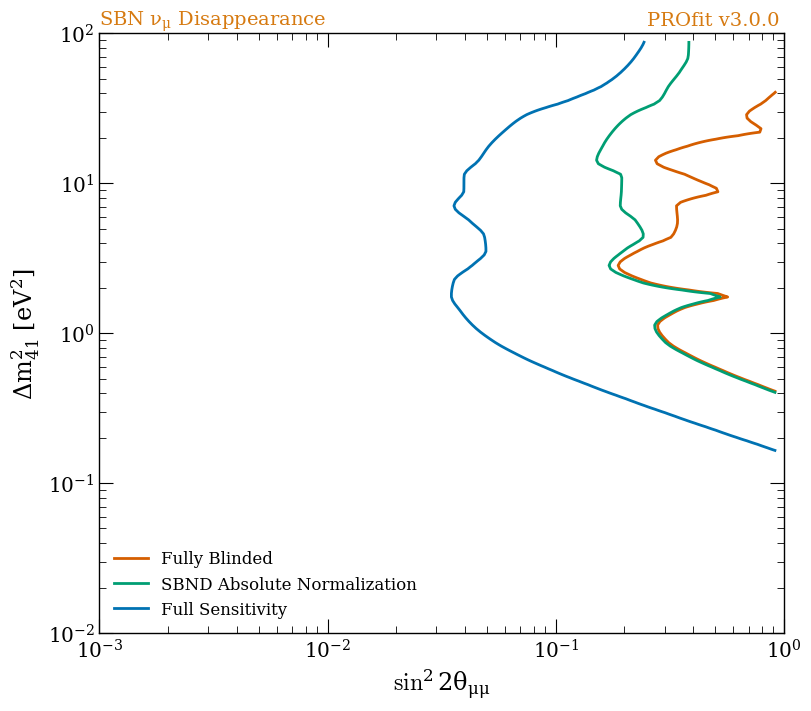

In [19]:
meta = [
    (PATH / 'contours_blind_v1_surf.root', r'Fully Blinded'),
    (PATH / 'contours_sbndunblind_v1_surf.root', r'SBND Absolute Normalization'),
    (PATH / 'contours_full_v1_surf.root', r'Full Sensitivity'),
]

plot_sensitivity(
    paths=[item[0] for item in meta],
    labels=[item[1] for item in meta],
    savefig='/Users/mueller/Projects/spineosc_sbnd_unblinding_request/figures/surface.pdf'
)

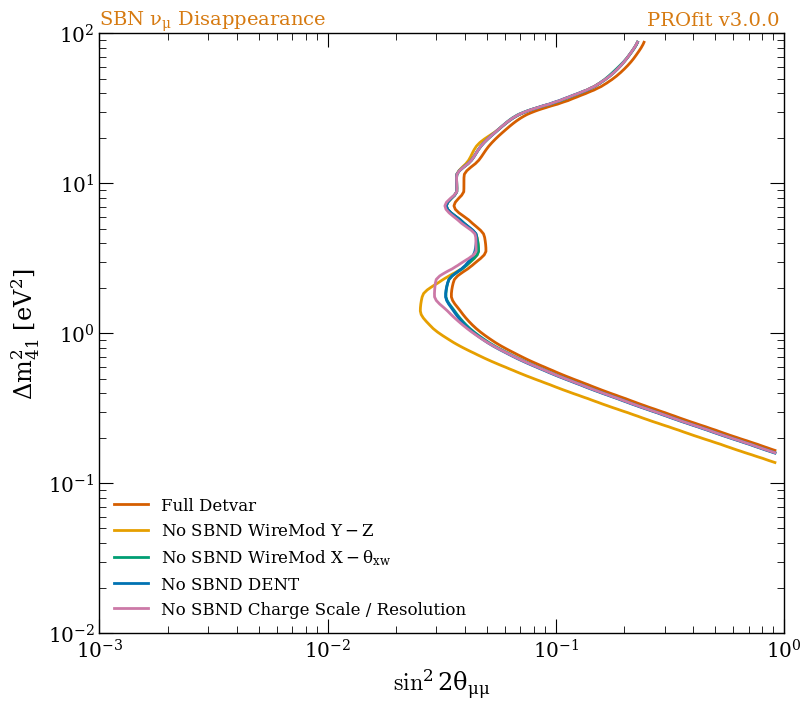

In [14]:
meta = [
    (PATH / 'contours_full_v1_surf.root', r'Full Detvar'),
    (PATH / 'contours_full_nowmyz_surf.root', r'No SBND WireMod $Y-Z$'),
    (PATH / 'contours_full_nowmxtxw_surf.root', r'No SBND WireMod $X-\theta_{xw}$'),
    (PATH / 'contours_full_nodent_surf.root', r'No SBND DENT'),
    (PATH / 'contours_full_nochargescale_surf.root', r'No SBND Charge Scale / Resolution'),
]

plot_sensitivity(
    paths=[item[0] for item in meta],
    labels=[item[1] for item in meta],
)